In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
#load data set
df = pd.read_csv("data/LoanEligibilityPrediction.csv")

In [101]:
#describe
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [103]:
#check out a few rows
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [104]:
df.head().T

,0,1,2,3,4
Customer_ID,569,15,95,134,556
Gender,Female,Male,Male,Male,Male
Married,No,Yes,No,Yes,Yes
Dependents,0,2,0,0,1
Education,Graduate,Graduate,Not Graduate,Graduate,Graduate
Self_Employed,No,No,No,Yes,No
Applicant_Income,2378,1299,3620,3459,5468
Coapplicant_Income,0.0,1086.0,0.0,0.0,1032.0
Loan_Amount,9,17,25,25,26
Loan_Amount_Term,360,120,120,120,360


In [105]:
#check for missing values
missing = pd.concat([df.isnull().sum(), 100 * df.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count')

,count,%
Customer_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
Applicant_Income,0,0.0
Coapplicant_Income,0,0.0
Loan_Amount,0,0.0
Loan_Amount_Term,0,0.0


In [106]:
#identify categorical variable columns
df.select_dtypes(include=object)

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Female,No,Graduate,No,Urban,N
1,Male,Yes,Graduate,No,Urban,Y
2,Male,No,Not Graduate,No,Semiurban,Y
3,Male,Yes,Graduate,Yes,Semiurban,Y
4,Male,Yes,Graduate,No,Semiurban,Y
...,...,...,...,...,...,...
609,Male,Yes,Graduate,No,Urban,N
610,Male,No,Graduate,No,Semiurban,N
611,Male,Yes,Graduate,Yes,Rural,N
612,Male,Yes,Not Graduate,No,Rural,Y


In [107]:
#inspect value domain of each categorical variable
print(df['Gender'].unique())
print(df['Married'].unique())
print(df['Education'].unique())
print(df['Self_Employed'].unique())
print(df['Property_Area'].unique())
print(df['Loan_Status'].unique())

['Female' 'Male']
['No' 'Yes']
['Graduate' 'Not Graduate']
['No' 'Yes']
['Urban' 'Semiurban' 'Rural']
['N' 'Y']


In [108]:
#validate customer id as key
df['Customer_ID'].is_unique

True

In [109]:
#set customer_id as index
df.set_index('Customer_ID', inplace=True)

In [110]:
#adding a new column for total income as that could be a big factor when determining eligibility
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']

In [111]:
#loan_amount is in the thousands
df['Full_Loan_Amount'] = df['Loan_Amount'] * 1000
#add monthly_payment
df['Monthly_Payment'] = (df['Full_Loan_Amount'] / df['Loan_Amount_Term']).round(2)
#add debt_to_income ratio
df['Debt_To_Income_Ratio'] = (df['Monthly_Payment'] / df['Total_Income'] * 100).round(2)

In [112]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Full_Loan_Amount,Monthly_Payment,Debt_To_Income_Ratio
Customer_ID,,,,,,,,,,,,,,,,
569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N,2378.0,9000,25.00,1.05
15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y,2385.0,17000,141.67,5.94
95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y,3620.0,25000,208.33,5.75
134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y,3459.0,25000,208.33,6.02
556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y,6500.0,26000,72.22,1.11


In [113]:
#slicing data by gender
female_df = df[df['Gender'] == 'Female']
male_df = df[df['Gender'] == 'Male']

#slicing data by approved/rejected
approved_df = df[df['Loan_Status'] == 'Y']
rejected_df = df[df['Loan_Status'] == 'N']

Text(0, 0.5, 'Income')

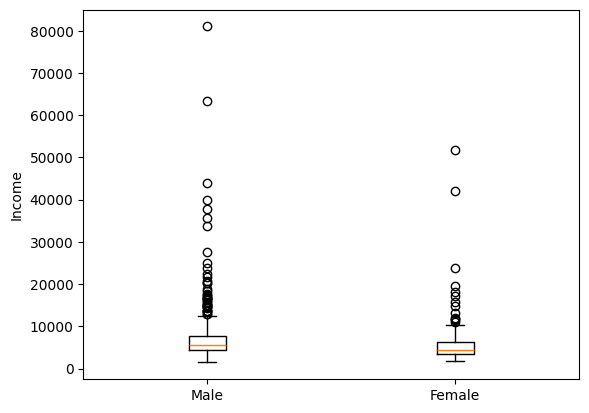

In [114]:
fig, ax = plt.subplots()
ax.boxplot([male_df['Total_Income'], female_df['Total_Income']])
ax.set_xticklabels(['Male', 'Female'])
ax.set_ylabel('Income')

There seems to some outliers in the income column. Let's check for outliers when sliced by approved/rejected

Text(0, 0.5, 'Income')

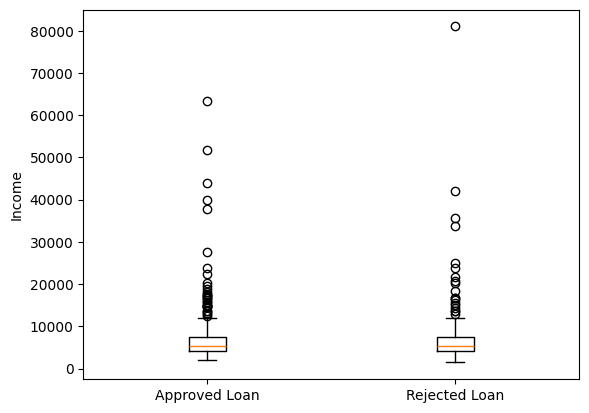

In [115]:
fig, ax = plt.subplots()
ax.boxplot([approved_df['Total_Income'], rejected_df['Total_Income']])
ax.set_xticklabels(['Approved Loan', 'Rejected Loan'])
ax.set_ylabel('Income')

Even sliced by approval outcome, there are still outliers. Checking loan to income ratio

Text(0, 0.5, 'Debt to Income Ratio')

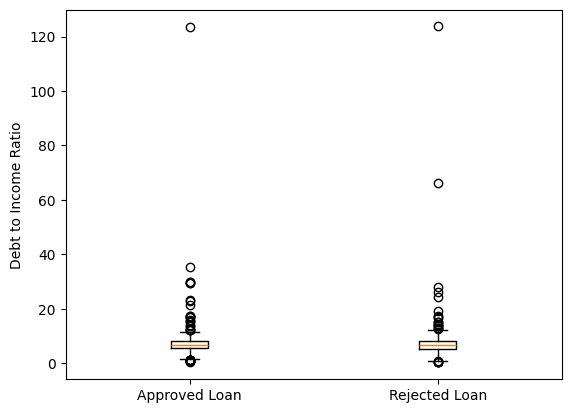

In [116]:
fig, ax = plt.subplots()
ax.boxplot([approved_df['Debt_To_Income_Ratio'], rejected_df['Debt_To_Income_Ratio']])
ax.set_xticklabels(['Approved Loan', 'Rejected Loan'])
ax.set_ylabel('Debt to Income Ratio')

Both approved and rejected datasets have outliers. What is weird is that there is a debt to income ratio on both datasets that are over 100%

In [117]:
#inspect outliers
sorted_by_dti = df.sort_values(by='Debt_To_Income_Ratio', ascending=False)
sorted_by_dti[['Total_Income', 'Full_Loan_Amount', 'Loan_Amount_Term', 'Monthly_Payment', 'Debt_To_Income_Ratio', 'Loan_Status', 'Credit_History']].head(10)

,Total_Income,Full_Loan_Amount,Loan_Amount_Term,Monthly_Payment,Debt_To_Income_Ratio,Loan_Status,Credit_History
Customer_ID,,,,,,,
263,3481.0,155000,36,4305.56,123.69,N,1
498,7482.0,111000,12,9250.00,123.63,Y,0
547,3358.0,80000,36,2222.22,66.18,N,1
576,3620.0,108000,84,1285.71,35.52,Y,1
314,5746.0,144000,84,1714.29,29.83,Y,1
243,8666.0,155000,60,2583.33,29.81,Y,1
496,4239.0,105000,84,1250.00,29.49,Y,1
69,7100.0,125000,60,2083.33,29.34,Y,1
586,7283.0,172000,84,2047.62,28.12,N,1


It looks like one applicant with id=498 had a Debt to Income ratio that is over 100% that was approved, and another one with id=263 that was rejected. The one that was approved has a shorter loan term so this is why his monthly payments are high. Still strange that this loan is approved, how can the applicant afford to pay the monthly loan?

What is also strange the approved application does not meet lending criteria credit history requirement. There could be other factors influencing credit approval or could this be bad data?

How much applications with credit_history = 0 is approved?

In [118]:
approved_wo_credit_history = sorted_by_dti[(sorted_by_dti['Credit_History'] == 0) & (sorted_by_dti['Loan_Status'] == 'Y')]
approved_wo_credit_history.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Total_Income,Full_Loan_Amount,Monthly_Payment,Debt_To_Income_Ratio
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.0,10.000000,10.00000,10.000000,10.000000
mean,1.200000,7565.900000,2036.000000,178.00000,289.200000,0.0,9601.900000,178000.00000,1580.277000,18.991000
std,1.619328,11445.236393,2722.040125,150.42163,122.826707,0.0,10876.299733,150421.62965,2848.616286,36.820674
min,0.000000,2137.000000,0.000000,90.00000,12.000000,0.0,3541.000000,90000.00000,311.110000,3.420000
25%,0.000000,3447.250000,0.000000,112.25000,225.000000,0.0,4929.500000,112250.00000,365.972500,6.802500
50%,0.500000,4479.000000,1620.500000,133.50000,360.000000,0.0,6188.000000,133500.00000,445.830000,7.835000
75%,1.750000,4921.500000,2728.500000,160.75000,360.000000,0.0,7290.250000,160750.00000,490.277500,9.225000
max,4.000000,39999.000000,8980.000000,600.00000,360.000000,0.0,39999.000000,600000.00000,9250.000000,123.630000


In [119]:
#inspect approved applications without meeting credit history requirement
approved_wo_credit_history[['Total_Income', 'Full_Loan_Amount', 'Loan_Amount_Term', 'Monthly_Payment', 'Debt_To_Income_Ratio', 'Loan_Status', 'Credit_History']].head(10)

,Total_Income,Full_Loan_Amount,Loan_Amount_Term,Monthly_Payment,Debt_To_Income_Ratio,Loan_Status,Credit_History
Customer_ID,,,,,,,
498,7482.0,111000,12,9250.00,123.63,Y,0
454,4949.0,90000,180,500.00,10.10,Y,0
202,4923.0,166000,360,461.11,9.37,Y,0
319,3541.0,112000,360,311.11,8.79,Y,0
156,39999.0,600000,180,3333.33,8.33,Y,0
327,4917.0,130000,360,361.11,7.34,Y,0
268,6144.0,160000,360,444.44,7.23,Y,0
528,6715.0,161000,360,447.22,6.66,Y,0
199,6232.0,113000,360,313.89,5.04,Y,0


It seems like id=498 is an outlier since those approved without credit history only has a debt_to_income_ratio < 11%. Deciding this is bad data and dropping this row below

In [120]:
clean_df = df.drop(index=498) 
clean_sorted_by_dti = clean_df.sort_values(by='Debt_To_Income_Ratio', ascending=False)
clean_sorted_by_dti[['Total_Income', 'Full_Loan_Amount', 'Loan_Amount_Term', 'Monthly_Payment', 'Debt_To_Income_Ratio', 'Loan_Status', 'Credit_History']].head(10)

,Total_Income,Full_Loan_Amount,Loan_Amount_Term,Monthly_Payment,Debt_To_Income_Ratio,Loan_Status,Credit_History
Customer_ID,,,,,,,
263,3481.0,155000,36,4305.56,123.69,N,1
547,3358.0,80000,36,2222.22,66.18,N,1
576,3620.0,108000,84,1285.71,35.52,Y,1
314,5746.0,144000,84,1714.29,29.83,Y,1
243,8666.0,155000,60,2583.33,29.81,Y,1
496,4239.0,105000,84,1250.00,29.49,Y,1
69,7100.0,125000,60,2083.33,29.34,Y,1
586,7283.0,172000,84,2047.62,28.12,N,1
37,3158.0,100000,120,833.33,26.39,N,0


Text(0, 0.5, 'Debt to Income Ratio')

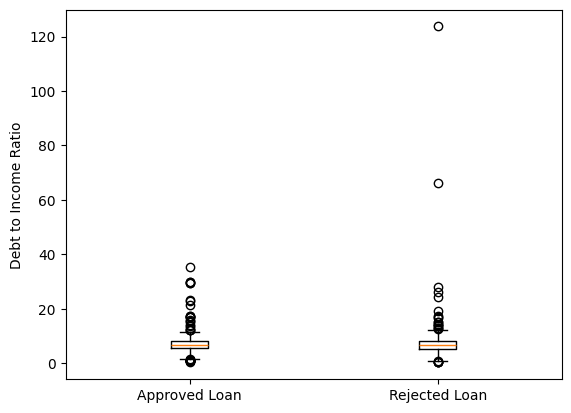

In [121]:
#slicing cleaned data 
female_df = clean_df[clean_df['Gender'] == 'Female']
male_df = clean_df[clean_df['Gender'] == 'Male']
approved_df = clean_df[clean_df['Loan_Status'] == 'Y']
rejected_df = clean_df[clean_df['Loan_Status'] == 'N']
fig, ax = plt.subplots()
ax.boxplot([approved_df['Debt_To_Income_Ratio'], rejected_df['Debt_To_Income_Ratio']])
ax.set_xticklabels(['Approved Loan', 'Rejected Loan'])
ax.set_ylabel('Debt to Income Ratio')

The box plot above looks better with the max debt to income ratio for approved applications < 40%. It seems like there are more factors when determining approval as a lot of rejected loans are very low debt to income ratio


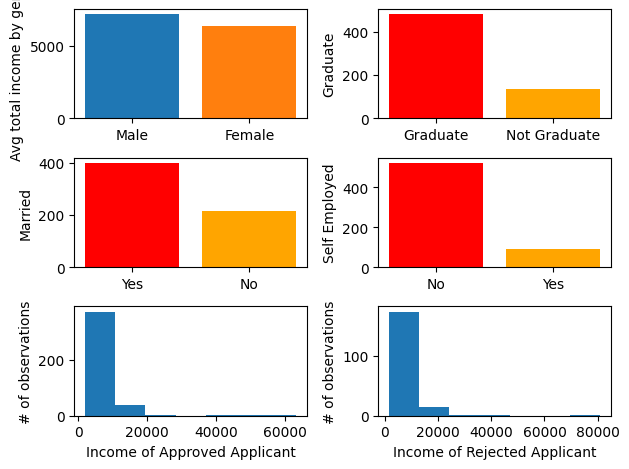

In [122]:
#More data exploration by visualization

#sns.countplot(x=df['Gender']) #getting errors with my seaborn package

#Income
fig, ax = plt.subplots(3, 2)
ax[0, 0].bar("Male", male_df["Total_Income"].mean())
ax[0, 0].bar("Female", female_df["Total_Income"].mean())
ax[0, 0].set_ylabel("Avg total income by gender")

#Education
educ_count = df['Education'].value_counts()
educ_cat = educ_count.index
educ_val = educ_count.values

ax[0, 1].bar(educ_cat, educ_val, color=['red', 'orange'])
ax[0, 1].set_ylabel("Graduate")

#Married
married_count = df['Married'].value_counts()
married_cat = married_count.index
married_val = married_count.values

ax[1, 0].bar(married_cat, married_val, color=['red', 'orange'])
ax[1, 0].set_ylabel("Married")

#Self Employed
selfemp_count = df['Self_Employed'].value_counts()
selfemp_cat = selfemp_count.index
selfemp_val = selfemp_count.values

ax[1, 1].bar(selfemp_cat, selfemp_val, color=['red', 'orange'])
ax[1, 1].set_ylabel("Self Employed")

#Income for approved
ax[2, 0].hist(approved_df['Total_Income'], bins=7)
ax[2, 0].set_xlabel("Income of Approved Applicant")
ax[2, 0].set_ylabel("# of observations")

#Income for approved
ax[2, 1].hist(rejected_df['Total_Income'], bins=7)
ax[2, 1].set_xlabel("Income of Rejected Applicant")
ax[2, 1].set_ylabel("# of observations")

plt.tight_layout()
plt.show()

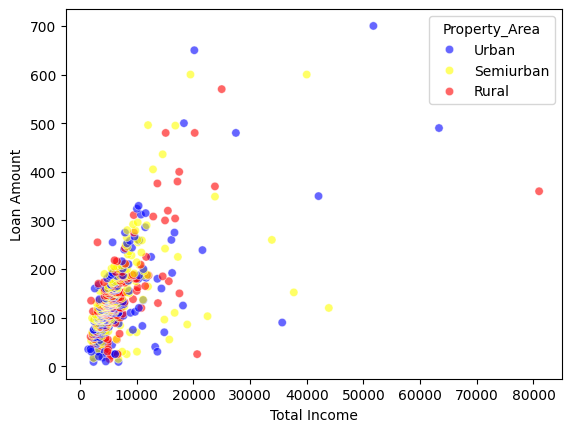

In [123]:
#update packages to use sns
#!pip install --upgrade pandas numpy matplotlib seaborn scipy
#plt.subplots(figsize=(12,10))
#sns.heatmap(df.corr(numeric_only=True));
sns.scatterplot(x=clean_df["Total_Income"], y=clean_df["Loan_Amount"], alpha=0.6, hue=clean_df["Property_Area"], palette={"Urban": "blue", "Rural": "red", "Semiurban": "yellow"})
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.show()

In [124]:
clean_df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Full_Loan_Amount,Monthly_Payment,Debt_To_Income_Ratio
Customer_ID,,,,,,,,,,,,,,,,
569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N,2378.0,9000,25.00,1.05
15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y,2385.0,17000,141.67,5.94
95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y,3620.0,25000,208.33,5.75
134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y,3459.0,25000,208.33,6.02
556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y,6500.0,26000,72.22,1.11


In [125]:
#Map yes/no data fields to something numeric for pearson coefficient
gender_mapping = {'Male': 1, 'Female': 0}
yes_no_mapping = {'Yes': 1, 'No': 0}
edu_mapping = {'Graduate': 1, 'Not Graduate': 0}
loan_status_mapping = {'Y': 1, 'N': 0}

clean_df['Gender_N'] = clean_df['Gender'].map(gender_mapping)
clean_df['Married_N'] = clean_df['Married'].map(yes_no_mapping)
clean_df['Self_Employed_N'] = clean_df['Self_Employed'].map(yes_no_mapping)
clean_df['Education_N'] = clean_df['Education'].map(edu_mapping)
clean_df['Loan_Status_N'] = clean_df['Loan_Status'].map(loan_status_mapping)

clean_df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,...,Loan_Status,Total_Income,Full_Loan_Amount,Monthly_Payment,Debt_To_Income_Ratio,Gender_N,Married_N,Self_Employed_N,Education_N,Loan_Status_N
Customer_ID,,,,,,,,,,,,,,,,,,,,,
569,Female,No,0,Graduate,No,2378,0.0,9,360,1,...,N,2378.0,9000,25.00,1.05,0,0,0,1,0
15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,...,Y,2385.0,17000,141.67,5.94,1,1,0,1,1
95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,...,Y,3620.0,25000,208.33,5.75,1,0,0,0,1
134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,...,Y,3459.0,25000,208.33,6.02,1,1,1,1,1
556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,...,Y,6500.0,26000,72.22,1.11,1,1,0,1,1


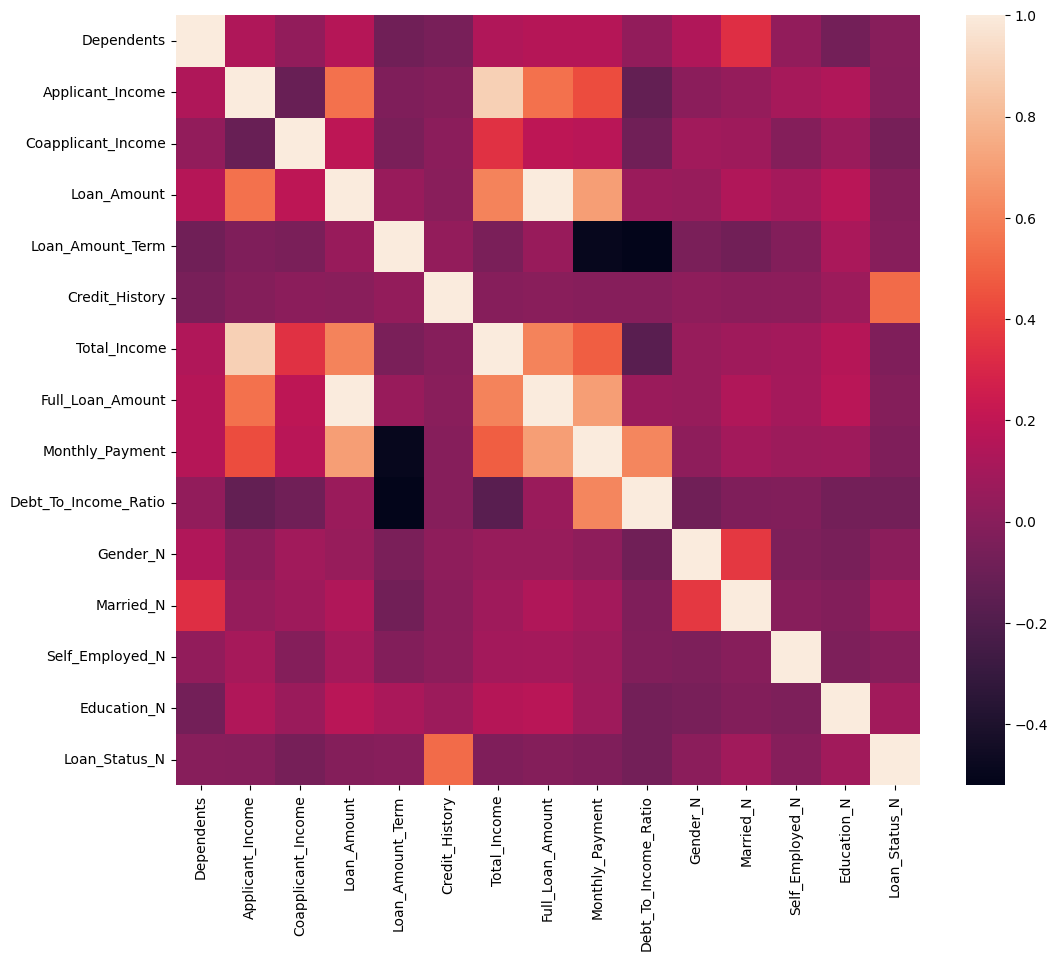

In [126]:
#update packages to use sns
#!pip install --upgrade pandas numpy matplotlib seaborn scipy
plt.subplots(figsize=(12,10))
sns.heatmap(clean_df.corr(numeric_only=True));

Seems like credit history has a strong correlation between meeting credit history (meeting lending criteria) and loan being approved. Marital status and educational status has positive correlation also. Strangely debt to income ratio does not seem to have that strong of a correlation with loan application being approved or not